# Monster-collecting game clone, part 2: overworld, wild encounters, and the capstone
* lesson 37 built PART 1 of this monster-collecting game clone: original, non-trademarked creature species, elemental types, moves, a type-effectiveness chart, a turn-based battle system and a catching mechanic
* THIS lesson builds PART 2, the capstone of this two-part mini-arc: the actual world you walk around in to find and use those creatures - a tile-based overworld with wild creatures hiding in tall grass, a trainer NPC who challenges you to a real battle, a "creature registry" (a Pokedex-style log of every species you've seen and caught), and finally a full scripted playthrough tying everything together
* just like lesson 32 mirrored lesson 18's capstone style for the RPG arc, this lesson closes out this mini-arc the exact same way
* this notebook is fully self-contained - we rebuild a small, SIMPLIFIED version of lesson 37's creature/battle system ourselves from scratch instead of importing anything from that notebook. the real focus of THIS lesson is the overworld/encounter/trainer systems, not re-deriving lesson 37's full depth

## setup (recap lesson 27's headless pygame trick)
* same trick as every lesson in this game-dev arc: set the SDL dummy video/audio drivers BEFORE `import pygame`, so it renders off-screen into memory instead of trying (and failing) to open a real window on this headless server
* we fix `random.seed(42)` right away too - we use randomness for wild encounter rolls, damage variance and the catching mechanic, and a fixed seed means EVERYONE running this notebook gets the exact same playthrough, every single time

In [1]:
import os

# these two MUST be set before "import pygame" - required only for this headless notebook environment (recap lesson 27)
os.environ["SDL_VIDEODRIVER"] = "dummy"   # render off-screen, no real display attached to this server
os.environ["SDL_AUDIODRIVER"] = "dummy"   # no real sound device needed for this lesson either

import pygame
import numpy as np
import matplotlib.pyplot as plt
import random  # for wild encounter rolls, damage variance and the catching mechanic - all reproducible via the seed below
from dataclasses import dataclass, field  # we use @dataclass for our simplified Move/CreatureSpecies records (recap lesson 10)

pygame.init()
pygame.font.init()  # its own subsystem, needed for the battle screen text and hp numbers


def show_surface(surface, title=None, figsize=(5, 4)):
    """Render a pygame Surface inline in the notebook (recap lesson 27)."""
    pixel_array = pygame.surfarray.array3d(surface).swapaxes(0, 1)  # pygame is (w, h, c), matplotlib wants (h, w, c)
    plt.figure(figsize=figsize)
    plt.imshow(pixel_array)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


random.seed(42)  # fixed seed - every random.random()/random.randint()/random.choice() call below becomes fully reproducible

FONT = pygame.font.SysFont(None, 18)  # pygame's built-in default font, small size fits our little screen nicely

print("pygame ready - lets rebuild a simplified creature/battle system, then build the world around it")

pygame 2.6.1 (SDL 2.28.4, Python 3.11.15)
Hello from the pygame community. https://www.pygame.org/contribute.html


pygame ready - lets rebuild a simplified creature/battle system, then build the world around it


## recap: a simplified creature/type/move/battle system (recap lesson 37's ideas)
* lesson 37 built this in full depth - here we rebuild a lean, compatible version ourselves, just enough to power the overworld systems this lesson is actually about
* `Move` and `CreatureSpecies` are plain `@dataclass` records (recap lesson 10) - all data, no behaviour, exactly what a dataclass is for
* `TYPE_CHART` is a small nested dict: `TYPE_CHART[attacking_type][defending_type]` gives the damage multiplier. any matchup we didn't bother listing falls back to a neutral `1.0` via `.get()` with a default - we only need to list the SUPER-effective and NOT-very-effective matchups explicitly
* `Creature` is one actual instance of a species at a given level - its stats scale up a little with every level, the same basic idea as an RPG leveling system (recap lesson 32's `Character` class)

In [2]:
@dataclass
class Move:
    """A single attack move. Just data - the actual damage math lives in calculate_damage() below."""
    name: str        # display name, e.g. "Ember Spark"
    move_type: str   # one of our four elemental types - "fire", "water", "grass" or "normal"
    power: int       # base power - higher means more damage, fed straight into our damage formula


@dataclass
class CreatureSpecies:
    """A KIND of creature (like a 'class' of monster) - every individual Creature instance points back to one of these."""
    name: str             # species display name, e.g. "Emberling"
    creature_type: str    # its elemental type, used for the type-effectiveness chart
    base_hp: int           # starting point for max hp at level 1, then scales up with level
    base_attack: int
    base_defense: int
    base_speed: int        # higher speed acts FIRST in battle - this drives our turn order below
    moves: list             # a list of Move objects this species knows
    catch_rate: float       # 0.0-1.0 baseline chance of a successful catch (recap lesson 37's catching mechanic)


# our simplified type chart - only the interesting matchups are listed, everything else defaults to a neutral 1.0x
TYPE_CHART = {
    "fire":   {"grass": 2.0, "water": 0.5, "fire": 0.5},  # fire burns grass, but water douses fire and fire resists fire
    "water":  {"fire": 2.0, "grass": 0.5, "water": 0.5},  # water beats fire, but grass soaks up water
    "grass":  {"water": 2.0, "fire": 0.5, "grass": 0.5},  # grass drinks up water, but fire burns right through grass
    "normal": {},  # normal has no special matchups in our simplified chart - always neutral
}


def type_effectiveness(move_type, defender_type):
    """Look up the damage multiplier for move_type attacking defender_type. Missing entries default to 1.0 (neutral)."""
    return TYPE_CHART.get(move_type, {}).get(defender_type, 1.0)


class Creature:
    """One actual creature - a species PLUS a level, with real hp that goes down in battle."""

    def __init__(self, species: CreatureSpecies, level: int):
        self.species = species
        self.level = level
        # simple, lean stat growth: base stat plus a bit more per level - real games use fancier curves, this is plenty for us
        self.max_hp = species.base_hp + level * 2
        self.hp = self.max_hp          # starts out at full health
        self.attack = species.base_attack + level
        self.defense = species.base_defense + level
        self.speed = species.base_speed + level

    @property
    def is_alive(self) -> bool:
        """A computed property instead of a manually tracked flag - always in sync with self.hp (recap lesson 32)."""
        return self.hp > 0

    def take_damage(self, amount: int) -> None:
        """Reduce hp by amount, clamped so it never goes below 0."""
        self.hp = max(0, self.hp - amount)

    def __str__(self) -> str:
        return f"{self.species.name} (Lv.{self.level}, HP {self.hp}/{self.max_hp}, type: {self.species.creature_type})"


def calculate_damage(attacker: Creature, move: Move, defender: Creature) -> int:
    """Our damage formula: move power + attacker stat - defender stat, scaled by type effectiveness, plus a small swing."""
    type_multiplier = type_effectiveness(move.move_type, defender.species.creature_type)
    base_damage = max(1, move.power + attacker.attack - defender.defense)  # never let the base drop to 0 or below
    swing = random.randint(-1, 1)  # a little variance so battles arent perfectly predictable, still reproducible via our seed
    return max(1, int(base_damage * type_multiplier) + swing)  # clamp again - the swing shouldnt be able to zero it out


def attempt_catch(creature: Creature) -> bool:
    """The catching mechanic (recap lesson 37): lower hp makes a creature much easier to catch, a classic genre convention."""
    hp_ratio = creature.hp / creature.max_hp  # 1.0 = full health, 0.0 = about to faint
    catch_chance = creature.species.catch_rate * (1.3 - hp_ratio)  # low hp pushes this well above the base catch_rate
    return random.random() < min(catch_chance, 0.95)  # cap it below 100% - even a nearly-fainted creature can still wriggle free


print("simplified Move / CreatureSpecies / Creature classes ready, plus calculate_damage() and attempt_catch()")

simplified Move / CreatureSpecies / Creature classes ready, plus calculate_damage() and attempt_catch()


## our creature species pool (original names, generic elemental types)
* four small original species: **Emberling** (fire), **Aqualing** (water), **Leaflet** (grass) and **Rockling** (normal) - each with one signature move plus the reliable, always-available `Tackle`
* `Emberling` is our player's starting creature; `Leaflet` and `Rockling` make up THIS area's wild pool found out in the tall grass - `Aqualing` sits this one out, a fire-type starter is at a real type disadvantage against water, so this area intentionally only spawns matchups our starter can actually handle (a bigger, more varied region is exactly the kind of thing the extension ideas at the end suggest building)

In [3]:
# moves - shared building blocks, several species reuse the plain "Tackle" as their reliable backup move
tackle = Move(name="Tackle", move_type="normal", power=6)
ember_spark = Move(name="Ember Spark", move_type="fire", power=9)
water_jet = Move(name="Water Jet", move_type="water", power=9)
vine_snap = Move(name="Vine Snap", move_type="grass", power=9)
rock_roll = Move(name="Rock Roll", move_type="normal", power=8)

SPECIES = {
    "Emberling": CreatureSpecies(
        name="Emberling", creature_type="fire", base_hp=20, base_attack=7, base_defense=4, base_speed=7,
        moves=[ember_spark, tackle], catch_rate=0.40,
    ),
    "Aqualing": CreatureSpecies(
        name="Aqualing", creature_type="water", base_hp=19, base_attack=6, base_defense=5, base_speed=6,
        moves=[water_jet, tackle], catch_rate=0.55,
    ),
    "Leaflet": CreatureSpecies(
        name="Leaflet", creature_type="grass", base_hp=18, base_attack=6, base_defense=6, base_speed=5,
        moves=[vine_snap, tackle], catch_rate=0.60,
    ),
    "Rockling": CreatureSpecies(
        name="Rockling", creature_type="normal", base_hp=23, base_attack=5, base_defense=8, base_speed=3,
        moves=[rock_roll, tackle], catch_rate=0.65,
    ),
}

WILD_SPECIES_POOL = [SPECIES["Leaflet"], SPECIES["Rockling"]]  # what can show up in the tall grass this area (a fire-type starter matches up fine against both)

for species_name, species in SPECIES.items():
    print(f"{species_name:10s} - type: {species.creature_type:6s} catch_rate: {species.catch_rate}")

Emberling  - type: fire   catch_rate: 0.4
Aqualing   - type: water  catch_rate: 0.55
Leaflet    - type: grass  catch_rate: 0.6
Rockling   - type: normal catch_rate: 0.65


## the battle system (recap lesson 32's `run_battle`, extended with speed-based turn order and catching)
* `run_battle()` alternates turns just like lesson 32, but here whoever has the higher `speed` stat gets to act FIRST each turn - a genuinely different, more "genre-accurate" rule than lesson 32's simpler always-player-first RPG battles
* actions are still a hardcoded, SCRIPTED list - `("move", move_index)` to attack, `("catch", None)` to try catching (wild battles only!), `("flee", None)` to run away
* `allow_catch=False` is how we make trainer battles work - trying to catch a trainer's own creature just fails outright with a message, exactly like the real genre convention: you can only catch WILD creatures
* it returns `(log_lines, result, next_action_index)` - the `next_action_index` lets us feed the SAME scripted action list across several back-to-back battles later (handy for a trainer's whole team, one after another)

In [4]:
def run_battle(player_creature: Creature, enemy_creature: Creature, scripted_actions: list, action_index: int = 0, allow_catch: bool = True):
    """Run one battle until someone faints, the player flees, or a catch succeeds. Never waits for real input."""
    log = []

    while player_creature.is_alive and enemy_creature.is_alive:
        # grab the next scripted action, or just keep using the first move once we run past the end of the list
        if action_index < len(scripted_actions):
            action, action_arg = scripted_actions[action_index]
        else:
            action, action_arg = "move", 0
        action_index += 1

        if action == "flee":
            log.append(f"{player_creature.species.name} flees from the battle!")
            return log, "fled", action_index

        if action == "catch":
            if not allow_catch:
                # the whole point of allow_catch=False - trainers' own creatures can NEVER be caught, genre convention
                log.append("You can't catch another trainer's creature!")
            elif attempt_catch(enemy_creature):
                log.append(f"Gotcha! {enemy_creature.species.name} was caught!")
                return log, "caught", action_index
            else:
                log.append(f"The wild {enemy_creature.species.name} broke free!")
            # a catch attempt (successful or not) still uses up the whole turn - the enemy gets to retaliate below
            enemy_move = enemy_creature.species.moves[0]  # simple enemy "AI": always its first, signature move
            damage = calculate_damage(enemy_creature, enemy_move, player_creature)
            player_creature.take_damage(damage)
            log.append(f"{enemy_creature.species.name} uses {enemy_move.name}! {damage} damage to {player_creature.species.name} (HP {player_creature.hp}/{player_creature.max_hp}).")
            if not player_creature.is_alive:
                log.append(f"{player_creature.species.name} fainted!")
                return log, "defeat", action_index
            continue  # back to the top of the loop for the next scripted action

        # action == "move" - whoever is FASTER this turn attacks first (the genre-accurate rule this lesson adds)
        player_move = player_creature.species.moves[action_arg]
        enemy_move = enemy_creature.species.moves[0]

        def player_attacks():
            damage = calculate_damage(player_creature, player_move, enemy_creature)
            enemy_creature.take_damage(damage)
            effectiveness = type_effectiveness(player_move.move_type, enemy_creature.species.creature_type)
            note = " It's super effective!" if effectiveness > 1 else (" It's not very effective..." if effectiveness < 1 else "")
            log.append(f"{player_creature.species.name} uses {player_move.name}! {damage} damage to {enemy_creature.species.name} (HP {enemy_creature.hp}/{enemy_creature.max_hp}).{note}")

        def enemy_attacks():
            damage = calculate_damage(enemy_creature, enemy_move, player_creature)
            player_creature.take_damage(damage)
            log.append(f"{enemy_creature.species.name} uses {enemy_move.name}! {damage} damage to {player_creature.species.name} (HP {player_creature.hp}/{player_creature.max_hp}).")

        if player_creature.speed >= enemy_creature.speed:  # ties go to the player, simplest rule that's still deterministic
            player_attacks()
            if not enemy_creature.is_alive:
                log.append(f"{enemy_creature.species.name} fainted!")
                return log, "victory", action_index
            enemy_attacks()
            if not player_creature.is_alive:
                log.append(f"{player_creature.species.name} fainted!")
                return log, "defeat", action_index
        else:
            enemy_attacks()
            if not player_creature.is_alive:
                log.append(f"{player_creature.species.name} fainted!")
                return log, "defeat", action_index
            player_attacks()
            if not enemy_creature.is_alive:
                log.append(f"{enemy_creature.species.name} fainted!")
                return log, "victory", action_index

    return log, "ongoing", action_index  # should never really be reached, the while condition already covers both cases


def draw_hp_bar(surface, x, y, width, height, current_hp, max_hp, color):
    """A simple hp bar - a grey background rect, then a colored rect scaled to the current/max hp ratio (recap lesson 32)."""
    pygame.draw.rect(surface, (60, 60, 60), (x, y, width, height))
    fill_width = int(width * max(0, current_hp) / max_hp)
    pygame.draw.rect(surface, color, (x, y, fill_width, height))
    pygame.draw.rect(surface, (255, 255, 255), (x, y, width, height), 1)


def draw_battle_screen(player_creature: Creature, enemy_creature: Creature, message: str = ""):
    """Render a battle screen: both creatures' names, hp numbers and hp bars, plus an optional status message."""
    screen.fill((15, 15, 30))  # a dark "battle arena" background, distinct from the world's green tiles

    screen.blit(FONT.render(f"{player_creature.species.name} Lv.{player_creature.level}", True, (255, 255, 255)), (14, 16))
    screen.blit(FONT.render(f"HP {player_creature.hp}/{player_creature.max_hp}", True, (255, 255, 255)), (14, 34))
    draw_hp_bar(screen, 14, 52, 120, 14, player_creature.hp, player_creature.max_hp, (80, 200, 100))  # green for the player

    screen.blit(FONT.render(f"{enemy_creature.species.name} Lv.{enemy_creature.level}", True, (255, 255, 255)), (186, 16))
    screen.blit(FONT.render(f"HP {enemy_creature.hp}/{enemy_creature.max_hp}", True, (255, 255, 255)), (186, 34))
    draw_hp_bar(screen, 186, 52, 120, 14, enemy_creature.hp, enemy_creature.max_hp, (200, 80, 80))  # red for the opponent

    if message:
        screen.blit(FONT.render(message, True, (255, 220, 80)), (14, 210))
    return screen


print("run_battle(), draw_hp_bar() and draw_battle_screen() ready")

run_battle(), draw_hp_bar() and draw_battle_screen() ready


## the overworld tile map (recap lesson 31's list-of-strings style)
* three tile types this time: `#` = wall (blocks movement, think trees/fences), `.` = a plain walkable path, `,` = tall grass - ALSO walkable, but every step onto it rolls a random chance of a wild encounter
* just like lesson 31, the map is a plain python list of strings - one string per row, one character per tile - a super compact way to hand-design a little level

map is 10 tiles wide, 8 tiles tall -> 320x256 pixels


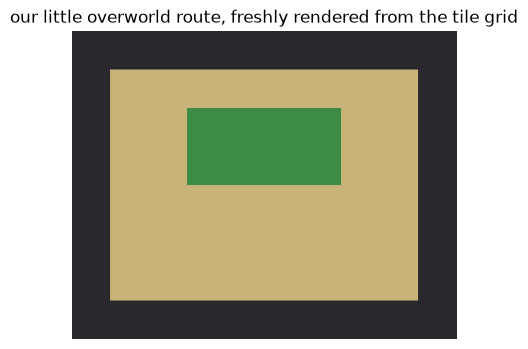

In [5]:
@dataclass
class TileType:
    """A plain data record for one kind of tile - color to draw it with, and whether characters can stand on it (recap lesson 31)."""
    color: tuple
    walkable: bool
    is_grass: bool = False  # only tall-grass tiles roll for a wild encounter when stepped on


TILE_TYPES = {
    "#": TileType(color=(40, 40, 45), walkable=False),                    # wall - dark grey, blocks movement entirely
    ".": TileType(color=(200, 180, 120), walkable=True),                  # path - tan, walkable, perfectly safe
    ",": TileType(color=(60, 140, 70), walkable=True, is_grass=True),     # tall grass - walkable, but can trigger an encounter
}

TILE_SIZE = 32  # each tile is a 32x32 pixel square on screen

# our little route: a walled-in area, a patch of tall grass in the middle, open ground near a trainer at the bottom
WORLD_MAP = [
    "##########",
    "#........#",
    "#..,,,,..#",
    "#..,,,,..#",
    "#........#",
    "#........#",
    "#........#",
    "##########",
]

MAP_ROWS = len(WORLD_MAP)
MAP_COLS = len(WORLD_MAP[0])
print(f"map is {MAP_COLS} tiles wide, {MAP_ROWS} tiles tall -> {MAP_COLS * TILE_SIZE}x{MAP_ROWS * TILE_SIZE} pixels")

screen = pygame.display.set_mode((MAP_COLS * TILE_SIZE, MAP_ROWS * TILE_SIZE))  # our shared "screen", reused for the world AND battles


def is_walkable_tile(world_map, grid_x, grid_y):
    """Can something stand on tile (grid_x, grid_y)? checks map bounds AND the tile's walkable flag (recap lesson 31)."""
    if grid_y < 0 or grid_y >= len(world_map):
        return False
    row = world_map[grid_y]
    if grid_x < 0 or grid_x >= len(row):
        return False
    return TILE_TYPES[row[grid_x]].walkable


def render_map(surface, world_map, tile_size):
    """Draw one rect per tile, converting grid coordinates to pixel coordinates (recap lesson 31)."""
    for row_index, row in enumerate(world_map):
        for col_index, tile_char in enumerate(row):
            color = TILE_TYPES[tile_char].color
            pixel_rect = (col_index * tile_size, row_index * tile_size, tile_size, tile_size)
            pygame.draw.rect(surface, color, pixel_rect)


render_map(screen, WORLD_MAP, TILE_SIZE)
show_surface(screen, title="our little overworld route, freshly rendered from the tile grid", figsize=(5, 4))

## quick standalone battle smoke test
* before wiring any of this into the real overworld playthrough, lets run one throwaway battle on its own, just to see the turn order, damage and battle screen actually working

before: Emberling (Lv.4, HP 28/28, type: fire)
before: Leaflet (Lv.3, HP 24/24, type: grass)


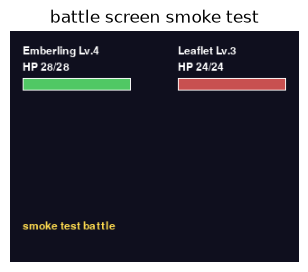

Emberling uses Ember Spark! 23 damage to Leaflet (HP 1/24). It's super effective!
Leaflet uses Vine Snap! 4 damage to Emberling (HP 24/28).
Emberling uses Ember Spark! 21 damage to Leaflet (HP 0/24). It's super effective!
Leaflet fainted!
result: victory


In [6]:
smoke_test_hero = Creature(SPECIES["Emberling"], level=4)
smoke_test_enemy = Creature(SPECIES["Leaflet"], level=3)

print("before:", smoke_test_hero)
print("before:", smoke_test_enemy)

show_surface(draw_battle_screen(smoke_test_hero, smoke_test_enemy, "smoke test battle"), title="battle screen smoke test", figsize=(4, 3))

smoke_test_actions = [("move", 0), ("move", 0), ("move", 0), ("move", 0)]  # just spam the signature move
smoke_log, smoke_result, _ = run_battle(smoke_test_hero, smoke_test_enemy, smoke_test_actions)
for line in smoke_log:
    print(line)
print("result:", smoke_result)

## the Player and the creature registry
* `Player` moves tile by tile, exactly like lesson 31's grid movement - `try_move()` checks the target tile is walkable AND isn't occupied by something else (like our trainer NPC) before actually moving there
* the player also carries a `party` - a plain list of `Creature` objects they currently own, and a `sprite_color` used to draw them on the map
* the **creature registry** is our little Pokedex-style log: a dict mapping `species name -> {"seen": bool, "caught": bool}`. `mark_seen()` records that we've encountered a species at all (even if we didn't catch it), `mark_caught()` records that it actually joined our party

In [7]:
class Player:
    """The character we control - grid position, a party of creatures, and tile-by-tile movement with collision."""

    def __init__(self, grid_x, grid_y, sprite_color, starter: Creature):
        self.grid_x = grid_x
        self.grid_y = grid_y
        self.sprite_color = sprite_color
        self.party = [starter]  # every player starts with exactly one creature already - recap lesson 37's catching mechanic gets us more

    def try_move(self, dx, dy, world_map, blocked_positions=()):
        """Attempt to move by (dx, dy). Returns True if it worked, False if a wall or something else blocked it."""
        new_x, new_y = self.grid_x + dx, self.grid_y + dy
        if not is_walkable_tile(world_map, new_x, new_y):
            return False  # a wall (or off the map entirely) - collision check #1
        if (new_x, new_y) in blocked_positions:
            return False  # something else (an NPC) is standing there - collision check #2
        self.grid_x, self.grid_y = new_x, new_y
        return True


registry = {}  # our creature registry: species name -> {"seen": bool, "caught": bool}, fills in as we play


def mark_seen(species_name):
    """Record that we've laid eyes on this species, even if we didn't catch it."""
    entry = registry.setdefault(species_name, {"seen": False, "caught": False})  # setdefault avoids overwriting an existing entry
    entry["seen"] = True


def mark_caught(species_name):
    """Record that this species actually joined our party. Being caught obviously implies being seen too."""
    entry = registry.setdefault(species_name, {"seen": False, "caught": False})
    entry["seen"] = True
    entry["caught"] = True


def print_registry(registry):
    """Print the whole registry so far, species we've never even seen simply dont show up at all yet."""
    print("=== Creature Registry ===")
    if not registry:
        print("  (empty so far)")
    for species_name in sorted(registry):
        entry = registry[species_name]
        status = "CAUGHT" if entry["caught"] else "seen only"
        print(f"  {species_name:10s}: {status}")


print("Player class and registry helpers ready")

Player class and registry helpers ready


## wild encounters - stepping onto tall grass
* every step onto a `,` (tall grass) tile rolls a fixed 30% chance of a wild creature jumping out - `random.random() < 0.30`
* when it doesn't trigger, absolutely nothing happens, the player just keeps walking - this is the classic "random chance per step" convention behind the whole genre
* when it DOES trigger, we pick a random species from `WILD_SPECIES_POOL` and give it a random low level, then hand back a fresh `Creature` ready to battle

In [8]:
ENCOUNTER_CHANCE = 0.30  # a fixed 30% chance per step onto tall grass, reproducible thanks to our seed


def maybe_trigger_wild_encounter(tile_char):
    """Roll for a wild encounter if this tile is tall grass. Returns a CreatureSpecies on a hit, or None otherwise."""
    if not TILE_TYPES[tile_char].is_grass:
        return None  # not even grass - no roll at all, walking on a path is always 100% safe
    if random.random() < ENCOUNTER_CHANCE:
        return random.choice(WILD_SPECIES_POOL)  # something rustles in the grass!
    return None  # this time, nothing happened


print("wild encounter system ready - ENCOUNTER_CHANCE is", ENCOUNTER_CHANCE)

wild encounter system ready - ENCOUNTER_CHANCE is 0.3


## the trainer NPC
* a `TrainerNPC` stands at a FIXED spot on the map, and owns its own little team of creatures (1-2, just like a real trainer battle)
* when the player approaches and interacts, it triggers a scripted BATTLE against the trainer's team, one creature after another - if the first one faints, the trainer sends out their next one, exactly like lesson 32's turn-based battles, just now chained across a whole team
* critically: `allow_catch=False` for every trainer sub-battle - you can NEVER catch another trainer's creatures, only wild ones out in the grass

In [9]:
class TrainerNPC:
    """An NPC standing at a fixed grid position, with a small team of their own creatures to battle."""

    def __init__(self, grid_x, grid_y, name, team):
        self.grid_x = grid_x
        self.grid_y = grid_y
        self.name = name
        self.team = team  # a list of Creature objects - the trainer sends them out one after another as they faint

    @property
    def position(self):
        return (self.grid_x, self.grid_y)


scout_trainer = TrainerNPC(
    grid_x=7, grid_y=5, name="Scout Talia",
    team=[
        Creature(SPECIES["Rockling"], level=3),  # tough and slow - a real damage sponge
        Creature(SPECIES["Leaflet"], level=3),   # weak to our fire-type starter, a nice comeback opportunity
    ],
)

print(f"{scout_trainer.name} is waiting at {scout_trainer.position} with a team of {len(scout_trainer.team)} creatures:")
for creature in scout_trainer.team:
    print(" -", creature)

# a tiny, throwaway illustration - trying to catch a trainer's creature is ALWAYS refused, no matter how low its hp is
# (we use fresh level-1 clones just for this demo, so it doesnt touch the real trainer's team or waste a real turn later)
demo_log, _, _ = run_battle(Creature(SPECIES["Emberling"], level=1), Creature(SPECIES["Rockling"], level=1), [("catch", None)], allow_catch=False)
print()
print("quick demo - trying to catch a trainer's creature:", demo_log[0])

Scout Talia is waiting at (7, 5) with a team of 2 creatures:
 - Rockling (Lv.3, HP 29/29, type: normal)
 - Leaflet (Lv.3, HP 24/24, type: grass)

quick demo - trying to catch a trainer's creature: You can't catch another trainer's creature!


## drawing the overworld
* same back-to-front drawing order as lesson 31/32: tiles first, then the trainer NPC, then the player LAST so it's always visible on top

In [10]:
def draw_world(world_map, player: Player, trainer: TrainerNPC):
    """Draw the whole overworld: tiles, then the trainer, then the player on top."""
    render_map(screen, world_map, TILE_SIZE)

    # the trainer - an orange square so its clearly a "person", not a wild creature
    trainer_pixel = (trainer.grid_x * TILE_SIZE + 4, trainer.grid_y * TILE_SIZE + 4, TILE_SIZE - 8, TILE_SIZE - 8)
    pygame.draw.rect(screen, (230, 140, 40), trainer_pixel)

    # the player - a colored circle drawn last, always on top of everything else
    center = (player.grid_x * TILE_SIZE + TILE_SIZE // 2, player.grid_y * TILE_SIZE + TILE_SIZE // 2)
    pygame.draw.circle(screen, player.sprite_color, center, TILE_SIZE // 2 - 4)
    return screen


print("draw_world() ready")

draw_world() ready


## putting it all together: the full scripted capstone playthrough
* our hero starts with one Emberling already, explores the world, wanders through the tall grass until a wild creature appears (some steps do nothing at all - that's the 30% chance working as intended!), fights and CATCHES it, then heads over to challenge the trainer and wins
* everything below is driven by hardcoded, SCRIPTED move lists - never a loop waiting for real keyboard input - and we grab a snapshot at every meaningful beat to look at as a little "comic strip" at the very end

hero starts with: Emberling (Lv.8, HP 36/36, type: fire)


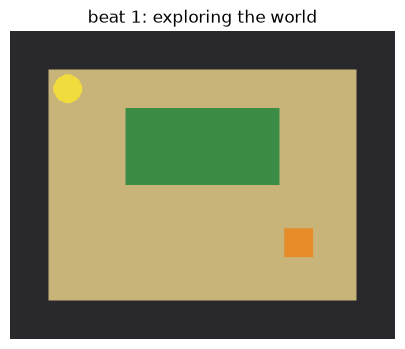

=== Creature Registry ===
  Emberling : CAUGHT


In [11]:
# --- beat 1: the hero sets out, starter Emberling already in the party -----------------------------------------
hero = Player(grid_x=1, grid_y=1, sprite_color=(240, 220, 60), starter=Creature(SPECIES["Emberling"], level=8))
mark_seen("Emberling")   # obviously - its our own starting creature, we've definitely "seen" it
mark_caught("Emberling")  # and it's already in our party, so it counts as caught too

snapshots = []  # (label, pixel_array) tuples we show together at the very end, comic-strip style

print("hero starts with:", hero.party[0])
surface = draw_world(WORLD_MAP, hero, scout_trainer)
snapshots.append(("1. exploring the world", pygame.surfarray.array3d(surface).swapaxes(0, 1).copy()))
show_surface(surface, title="beat 1: exploring the world")
print_registry(registry)

In [12]:
# --- beat 2: walk east along the top path, then into the tall grass patch --------------------------------------
print("walking east along the top path...")
for _ in range(4):
    hero.try_move(1, 0, WORLD_MAP, blocked_positions={scout_trainer.position})
print("hero is now at", (hero.grid_x, hero.grid_y))

# step down into the grass, then shuffle right/left inside it - a real player would just wander around a bit here too
grass_shuffle = [(0, 1)] + [(1, 0), (-1, 0)] * 10  # first step INTO the grass, then plenty of back-and-forth room to roll for encounters

encountered_species = None
for step_number, (dx, dy) in enumerate(grass_shuffle):
    hero.try_move(dx, dy, WORLD_MAP, blocked_positions={scout_trainer.position})
    tile_here = WORLD_MAP[hero.grid_y][hero.grid_x]
    tile_name = "tall grass" if TILE_TYPES[tile_here].is_grass else "path"
    print(f"step {step_number:2d}: now at {(hero.grid_x, hero.grid_y)} ({tile_name})")
    encountered_species = maybe_trigger_wild_encounter(tile_here)
    if encountered_species is not None:
        print(f"        -> something rustles in the grass! a wild {encountered_species.name} appears!")
        break
    elif TILE_TYPES[tile_here].is_grass:
        print("        -> just tall grass swaying in the wind, nothing happened this time")

print()
print("encounter triggered with species:", encountered_species.name if encountered_species else None)

walking east along the top path...
hero is now at (5, 1)
step  0: now at (5, 2) (tall grass)
        -> just tall grass swaying in the wind, nothing happened this time
step  1: now at (6, 2) (tall grass)
        -> just tall grass swaying in the wind, nothing happened this time
step  2: now at (5, 2) (tall grass)
        -> just tall grass swaying in the wind, nothing happened this time
step  3: now at (6, 2) (tall grass)
        -> something rustles in the grass! a wild Rockling appears!

encounter triggered with species: Rockling


a wild battle begins!
your creature: Emberling (Lv.8, HP 36/36, type: fire)
wild creature: Rockling (Lv.2, HP 27/27, type: normal)
=== Creature Registry ===
  Emberling : CAUGHT
  Rockling  : seen only


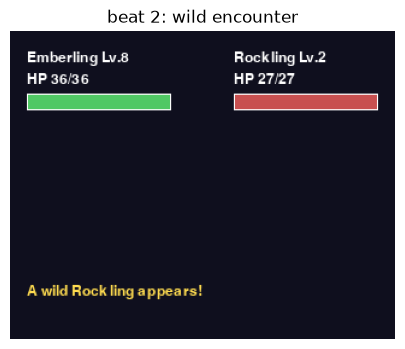

Emberling uses Ember Spark! 13 damage to Rockling (HP 14/27).
Rockling uses Rock Roll! 2 damage to Emberling (HP 34/36).
Gotcha! Rockling was caught!
battle result: caught
Rockling was added to the party!


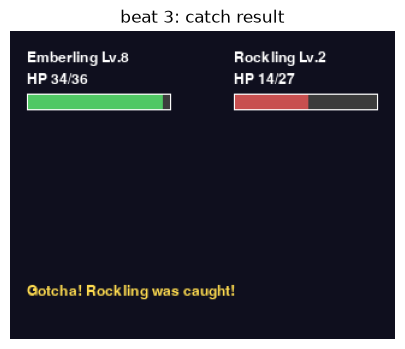

=== Creature Registry ===
  Emberling : CAUGHT
  Rockling  : CAUGHT


In [13]:
# --- beat 3: the wild battle - fight it down, then CATCH it -----------------------------------------------------
wild_creature = Creature(encountered_species, level=random.randint(2, 4))
mark_seen(wild_creature.species.name)  # we've now definitely seen this species, whether we catch it or not

print("a wild battle begins!")
print("your creature:", hero.party[0])
print("wild creature:", wild_creature)
print_registry(registry)

surface = draw_battle_screen(hero.party[0], wild_creature, f"A wild {wild_creature.species.name} appears!")
snapshots.append(("2. wild encounter", pygame.surfarray.array3d(surface).swapaxes(0, 1).copy()))
show_surface(surface, title="beat 2: wild encounter")

# scripted plan: soften it up a little, then try catching it a few times - low hp makes attempt_catch() far more likely to succeed
wild_actions = [("move", 0), ("catch", None), ("catch", None), ("catch", None), ("catch", None), ("catch", None)]
wild_log, wild_result, _ = run_battle(hero.party[0], wild_creature, wild_actions, allow_catch=True)
for line in wild_log:
    print(line)
print("battle result:", wild_result)

if wild_result == "caught":
    hero.party.append(wild_creature)          # it joins the party!
    mark_caught(wild_creature.species.name)   # and the registry now shows it as properly caught, not just seen
    print(f"{wild_creature.species.name} was added to the party!")

surface = draw_battle_screen(hero.party[0], wild_creature, f"Gotcha! {wild_creature.species.name} was caught!" if wild_result == "caught" else f"Result: {wild_result}")
snapshots.append(("3. caught!", pygame.surfarray.array3d(surface).swapaxes(0, 1).copy()))
show_surface(surface, title="beat 3: catch result")
print_registry(registry)

walking south out of the grass, towards the trainer...
moved to (6, 3)
moved to (6, 4)
moved to (6, 5)
blocked!
blocked!
tried to walk onto the trainer's own tile, blocked? True -> still at (6, 5)
distance to the trainer: 1 (1 means standing right next to them - close enough to battle!)


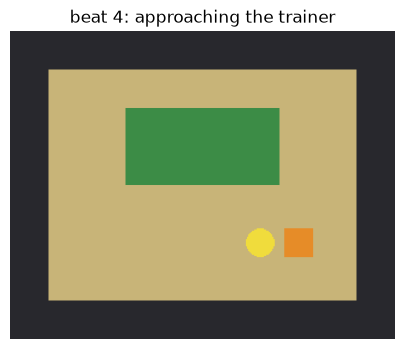

Scout Talia: "I've been training all week, let's battle!"


In [14]:
# --- beat 4: head towards the trainer, bump into them, and the battle triggers ----------------------------------
print("walking south out of the grass, towards the trainer...")
southward_and_east_moves = [(0, 1), (0, 1), (0, 1), (1, 0), (1, 0)]  # exit the grass, then head towards the trainer's column
for dx, dy in southward_and_east_moves:
    moved = hero.try_move(dx, dy, WORLD_MAP, blocked_positions={scout_trainer.position})
    print(f"moved to {(hero.grid_x, hero.grid_y)}" if moved else "blocked!")

# one deliberate bump straight into the trainer's own tile - proves our NPC-collision check works, same idea as lesson 31/32
bumped = hero.try_move(1, 0, WORLD_MAP, blocked_positions={scout_trainer.position})
print("tried to walk onto the trainer's own tile, blocked?", not bumped, "-> still at", (hero.grid_x, hero.grid_y))

distance_to_trainer = abs(hero.grid_x - scout_trainer.grid_x) + abs(hero.grid_y - scout_trainer.grid_y)
print("distance to the trainer:", distance_to_trainer, "(1 means standing right next to them - close enough to battle!)")

surface = draw_world(WORLD_MAP, hero, scout_trainer)
snapshots.append(("4. trainer battle", pygame.surfarray.array3d(surface).swapaxes(0, 1).copy()))
show_surface(surface, title="beat 4: approaching the trainer")
print(f"{scout_trainer.name}: \"I've been training all week, let's battle!\"")

Scout Talia sends out Rockling (Lv.3)!
your fighter: Emberling (Lv.8, HP 34/36, type: fire)


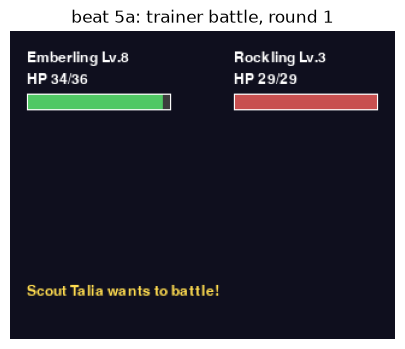

Emberling uses Ember Spark! 14 damage to Rockling (HP 15/29).
Rockling uses Rock Roll! 5 damage to Emberling (HP 29/36).
Emberling uses Ember Spark! 12 damage to Rockling (HP 3/29).
Rockling uses Rock Roll! 5 damage to Emberling (HP 24/36).
Emberling uses Ember Spark! 12 damage to Rockling (HP 0/29).
Rockling fainted!
round 1 result: victory

Scout Talia sends out Leaflet (Lv.3)!
your fighter: Emberling (Lv.8, HP 24/36, type: fire)
Emberling uses Ember Spark! 31 damage to Leaflet (HP 0/24). It's super effective!
Leaflet fainted!
round 2 result: victory

overall trainer battle result: victory


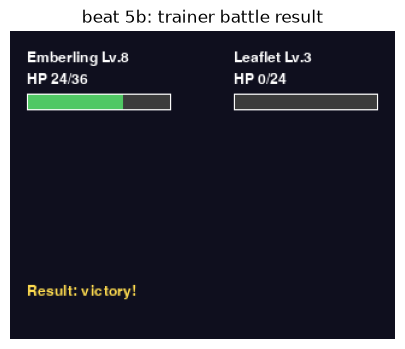

In [15]:
# --- beat 5: the trainer battle - one creature after another, no catching allowed -------------------------------
print(f"{scout_trainer.name} sends out {scout_trainer.team[0].species.name} (Lv.{scout_trainer.team[0].level})!")
print("your fighter:", hero.party[0])

surface = draw_battle_screen(hero.party[0], scout_trainer.team[0], f"{scout_trainer.name} wants to battle!")
show_surface(surface, title="beat 5a: trainer battle, round 1")

round_one_actions = [("move", 0)] * 6  # just keep hitting with our signature move, no catching allowed against a trainer anyway
round_one_log, round_one_result, _ = run_battle(hero.party[0], scout_trainer.team[0], round_one_actions, allow_catch=False)
for line in round_one_log:
    print(line)
print("round 1 result:", round_one_result)

overall_trainer_result = round_one_result
if round_one_result == "victory":
    # the trainer's first creature fainted - they send out their NEXT one (recap lesson 32-style team progression)
    # we send out whichever of OUR OWN creatures is currently healthiest (by hp ratio) - our own little party switch
    fighter_two = max((creature for creature in hero.party if creature.is_alive), key=lambda creature: creature.hp / creature.max_hp)
    print()
    print(f"{scout_trainer.name} sends out {scout_trainer.team[1].species.name} (Lv.{scout_trainer.team[1].level})!")
    print("your fighter:", fighter_two)

    round_two_actions = [("move", 0), ("move", 0), ("move", 0), ("move", 0), ("move", 0)]
    round_two_log, round_two_result, _ = run_battle(fighter_two, scout_trainer.team[1], round_two_actions, allow_catch=False)
    for line in round_two_log:
        print(line)
    print("round 2 result:", round_two_result)
    overall_trainer_result = round_two_result

print()
print("overall trainer battle result:", overall_trainer_result)

surface = draw_battle_screen(hero.party[0], scout_trainer.team[-1], f"Result: {overall_trainer_result}!")
snapshots.append(("5. victory!", pygame.surfarray.array3d(surface).swapaxes(0, 1).copy()))
show_surface(surface, title="beat 5b: trainer battle result")

=== final party ===
 - Emberling (Lv.8, HP 24/36, type: fire)
 - Rockling (Lv.2, HP 14/27, type: normal)

=== Creature Registry ===
  Emberling : CAUGHT
  Rockling  : CAUGHT

and that's a complete (tiny!) monster-collecting playthrough: explore -> wild encounter -> catch -> trainer battle -> win


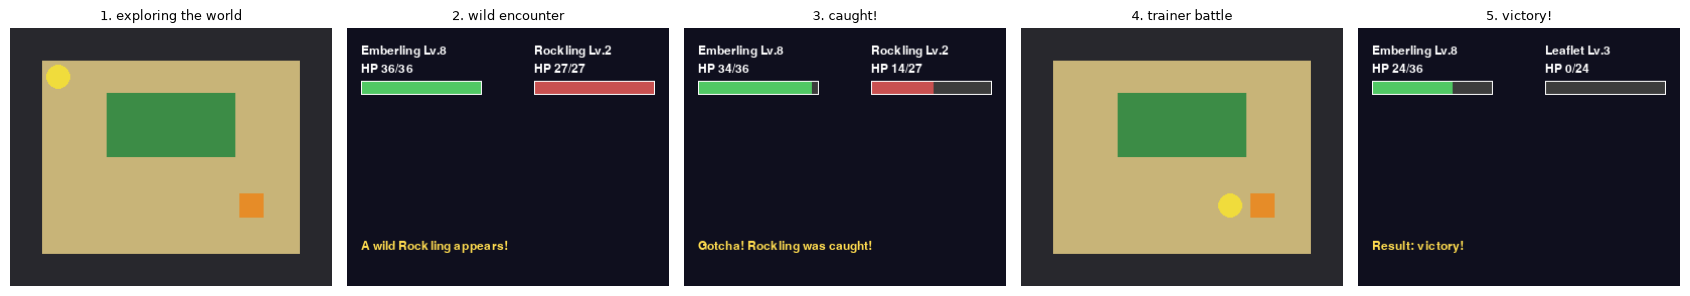

In [16]:
# --- the aftermath: final party, final registry, and the whole playthrough as one flipbook -----------------------
print("=== final party ===")
for creature in hero.party:
    print(" -", creature)

print()
print_registry(registry)

print()
print("and that's a complete (tiny!) monster-collecting playthrough: explore -> wild encounter -> catch -> trainer battle -> win")

fig, axes = plt.subplots(1, len(snapshots), figsize=(3.4 * len(snapshots), 3.2))
for ax, (label, pixels) in zip(axes, snapshots):
    ax.imshow(pixels)
    ax.set_title(label, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Ideas to extend this further
* the two-part arc ends here, but this little game absolutely doesnt have to - here are a few open-ended ideas to keep building on your own, no solutions provided this time!
* add a healing location (a "creature center" tile, or a healing item in an inventory) so the player can restore their party's hp between encounters instead of just hoping for the best
* add MULTIPLE wild species pools with different encounter rates per tile/area - a swampy area could favor water types, a rocky one favor normal types (recap lesson 30's procedural-generation ideas for varying terrain-appropriate content)
* add evolution - a creature transforms into a stronger species after reaching a certain level (recap lesson 35's leveling system), the same idea as an RPG's classic level-up moment
* add multiple trainers with increasingly strong teams, forming a simple "gym"-style progression the player works through one battle at a time
* add the multiplayer PvP battle idea from the networking lessons (33/34/36) so two players could battle their OWN parties against each other over the network - this is explicitly what lesson 39 will build!
* add a simple menu/UI state machine - an enum (recap lesson 10) of states like `EXPLORING`, `BATTLE`, `MENU`, `GAME_OVER` (recap lesson 32's own extension ideas for exactly this)

* congratulation, you finished the monster-collecting game clone arc!

## what we learned in this capstone
* rebuilt a lean, self-contained version of lesson 37's creature/type/move/battle system - `Move`/`CreatureSpecies` dataclasses, a small type-effectiveness chart, and a `Creature` class with level-based stats
* extended the turn-based battle loop with SPEED-based turn order (faster creature acts first) instead of always-player-first, and a catching mechanic where lower hp means a much better catch chance
* a tile-based overworld (recap lesson 31) with THREE tile types, where tall-grass tiles roll a random, reproducible chance of a wild encounter on every step
* a creature registry - a Pokedex-style dict tracking which species have been seen vs actually caught, updated live as the playthrough progresses
* a `TrainerNPC` with its own team, battled one creature after another, with catching explicitly disabled - the genre's classic "wild vs trainer" battle distinction
* tied it all together into one full scripted playthrough: explore -> wild encounter -> catch -> approach a trainer -> battle -> win -> final party and registry printout

## what we learned across this two-part mini-arc
* 37: original creature species, elemental types, moves, a type-effectiveness chart, a turn-based battle system and the catching mechanic that makes this genre what it is
* 38 (this one!): the overworld you actually explore with those creatures - wild encounters in tall grass, a trainer battle, a growing creature registry, and a complete playable capstone demo tying the whole two-part arc together

thank you for following along through this monster-collecting mini-arc - now go build a whole region of your own with it!